**Imports**

In [3]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

#check gpu is enabled
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"using device: {device}")

using device: cuda


**Define transforms**: 
-These exact mean and std values are NOT arbitrary.

-They come from the ImageNet dataset that ResNet was trained on.

-Using the same normalization = the model's pretrained weights stay valid.


JPEG file

   ↓  Resize(256,256)          → make all images same size
   
   ↓  RandomCrop(224)          → cut to 224×224 (ResNet's expected size)
   
   ↓  RandomHorizontalFlip()   → randomly mirror the image
   
   ↓  RandomRotation(15)       → tilt slightly
   
   ↓  ColorJitter()            → tweak brightness/contrast
   
   ↓  ToTensor()               → convert pixels to numbers 
   (0-255 → 0.0-1.0)
   
   ↓  Normalize()              → shift numbers to what ResNet expects
   
[3, 224, 224] tensor           → ready for the model

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

#training transforms- includes augmentation( so the model is trained on various images and doesnt memorize the exact images)
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),  #recize slightly bigger first
    transforms.RandomCrop(224),     #crop randomly to 224x224
    transforms.RandomHorizontalFlip(),  #flip image left-right 50% of time
    transforms.RandomRotation(15), #rotate randomly up to 15 degrees
    transforms.ColorJitter(
        brightness=0.2,  #randomly charge brightness
        contrast=0.2,    #and contrast
    ),
    transforms.ToTensor(), #convert PIl images to tense (0-255 -> 0.0-1.0)
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    ),
    
])

#validation transforms- no augmenttion just celan resize + norùalization
# we want to test on consistent unmodified images
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
         mean=IMAGENET_MEAN,
         std=IMAGENET_STD
            
    ),
])

**Load Dataset**

In [5]:
DATA_DIR= '/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color'

#imagefolder eads the folder structure automatically
#folder name-> class label
full_dataset = datasets.ImageFolder(root=DATA_DIR)

#check what wad loaded
print(f"total images: {len(full_dataset)}")
print(f"classes: {len(full_dataset.classes)}")
print(f"first 5 classes: {full_dataset.classes[:5]} ")

total images: 54305
classes: 38
first 5 classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy'] 


**Visualization**

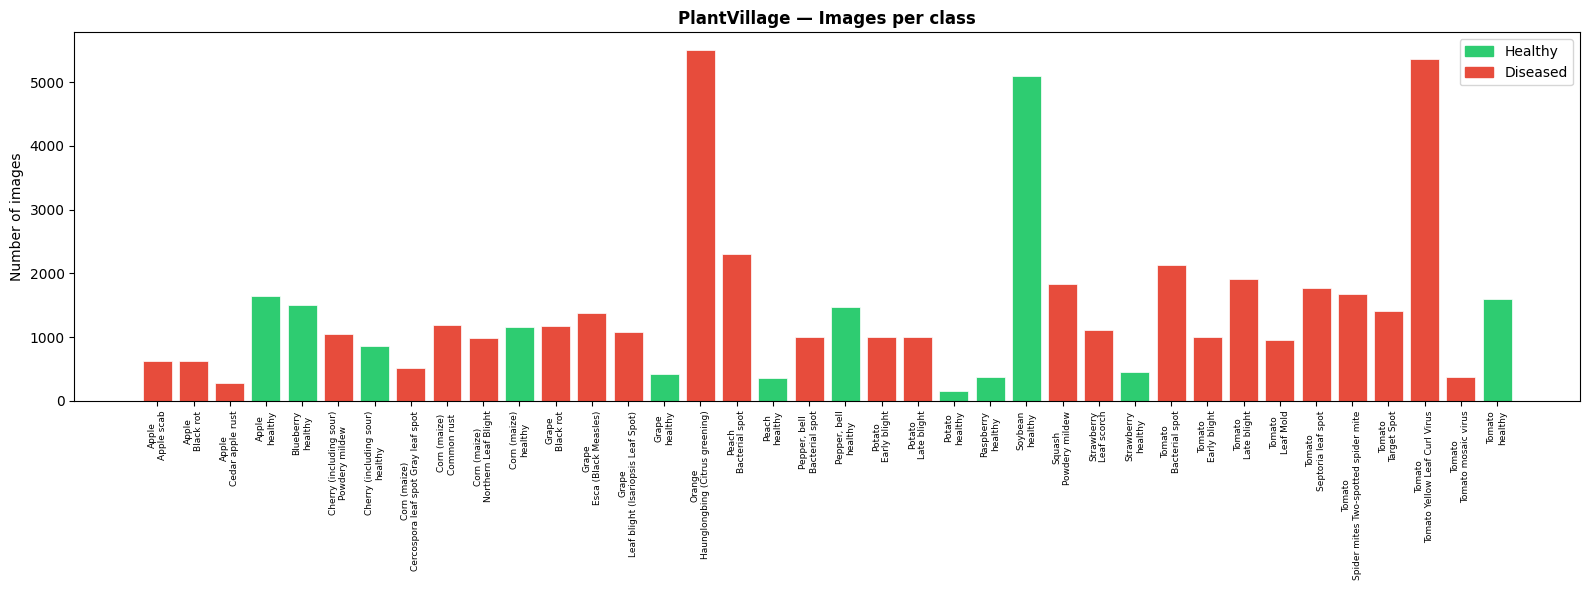

In [6]:
# ── 2. Bar chart — images per class ───────────────────────────────────
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
classes     = sorted(os.listdir(DATA_DIR))
class_counts = {cls: len(os.listdir(os.path.join(DATA_DIR, cls))) for cls in classes}
fig, ax = plt.subplots(figsize=(16, 6))

colors = ['#2ecc71' if 'healthy' in c else '#e74c3c' for c in class_counts.keys()]

ax.bar(range(len(class_counts)), class_counts.values(), color=colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(class_counts)))
ax.set_xticklabels(
    [c.replace('___', '\n').replace('_', ' ') for c in class_counts.keys()],
    rotation=90, fontsize=6.5
)
ax.set_ylabel('Number of images')
ax.set_title('PlantVillage — Images per class', fontweight='bold')

healthy_patch = mpatches.Patch(color='#2ecc71', label='Healthy')
disease_patch = mpatches.Patch(color='#e74c3c', label='Diseased')
ax.legend(handles=[healthy_patch, disease_patch])

plt.tight_layout()
plt.show()

In [7]:
from pathlib import Path

plants = {}
for class_dir in sorted(Path(DATA_DIR).iterdir()):
    if not class_dir.is_dir():
        continue
    parts = class_dir.name.split('___')
    if len(parts) != 2:
        continue
    plant, condition = parts
    images = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.JPG')) + list(class_dir.glob('*.png'))
    if not images:
        continue
    if plant not in plants:
        plants[plant] = {}
    if 'healthy' in condition.lower():
        plants[plant]['healthy'] = images[0]
    elif 'diseased' not in plants[plant]:
        plants[plant]['diseased'] = images[0]

plants = {k: v for k, v in plants.items() if 'healthy' in v and 'diseased' in v}
print(f"{len(plants)} plants found: {list(plants.keys())}")

9 plants found: ['Apple', 'Cherry_(including_sour)', 'Corn_(maize)', 'Grape', 'Peach', 'Pepper,_bell', 'Potato', 'Strawberry', 'Tomato']


In [8]:
from pathlib import Path
from collections import defaultdict

# Group classes by plant name
plant_groups = defaultdict(list)
for class_name in sorted(Path(DATA_DIR).iterdir()):
    if not class_name.is_dir():
        continue
    parts = class_name.name.split('___')
    if len(parts) != 2:
        continue
    plant, condition = parts
    plant_groups[plant].append(class_name.name)

# Build plants dict (healthy + one diseased image path per plant)
plants = {}
for plant, class_names in plant_groups.items():
    entry = {}
    for class_name in class_names:
        class_dir = Path(DATA_DIR) / class_name
        images = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.JPG')) + list(class_dir.glob('*.png'))
        if not images:
            continue
        if 'healthy' in class_name.lower():
            entry['healthy'] = images[0]
        elif 'diseased' not in entry:
            entry['diseased'] = images[0]
    if 'healthy' in entry and 'diseased' in entry:
        plants[plant] = entry

print(f"{len(plants)} plants | {sum(len(v) for v in plant_groups.values())} total classes")
print(f"plant_groups sample: { {k: v for k, v in list(plant_groups.items())[:2]} }")

9 plants | 38 total classes
plant_groups sample: {'Apple': ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy'], 'Blueberry': ['Blueberry___healthy']}


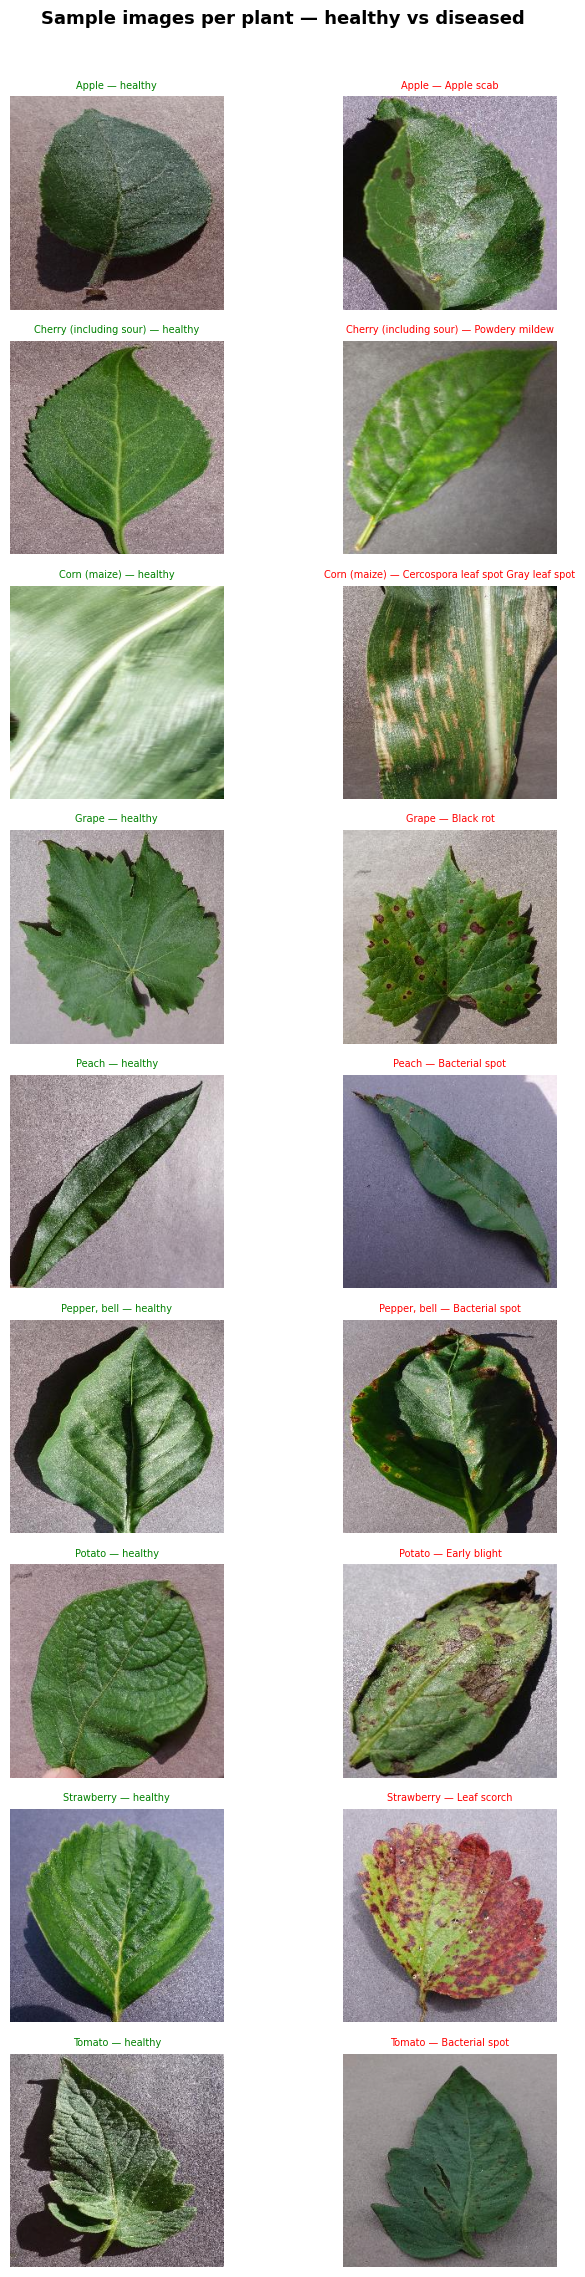

In [9]:
# Show one healthy + one diseased image per plant
from PIL import Image
fig, axes = plt.subplots(len(plants), 2, figsize=(8, len(plants) * 2.5))
fig.suptitle('Sample images per plant — healthy vs diseased', 
             fontsize=13, fontweight='bold', y=1.01)

for i, plant in enumerate(plants):
    plant_classes = plant_groups[plant]
    
    healthy = [c for c in plant_classes if 'healthy' in c]
    diseased = [c for c in plant_classes if 'healthy' not in c]

    for j, (category, label) in enumerate([(healthy, 'healthy'), (diseased, 'diseased')]):
        ax = axes[i][j]
        if category:
            cls_folder = os.path.join(DATA_DIR, category[0])
            img_file   = os.listdir(cls_folder)[0]         # grab first image
            img        = Image.open(os.path.join(cls_folder, img_file)).convert('RGB')
            
            ax.imshow(img)
            short = category[0].replace('___', ' — ').replace('_', ' ')
            ax.set_title(short, fontsize=7, color='green' if label=='healthy' else 'red')
        else:
            ax.text(0.5, 0.5, 'No sample', ha='center', va='center')
        ax.axis('off')

plt.tight_layout()
plt.show()

**SPLIT**

In [10]:
#split: 80% train 20% test
from torch.utils.data import Subset
# two separate dataset objects, transforms baked in from the start
train_dataset_full = datasets.ImageFolder(root=DATA_DIR, transform=train_transforms)
val_dataset_full   = datasets.ImageFolder(root=DATA_DIR, transform=val_transforms)

total      = len(train_dataset_full)
train_size = int(0.8 * total)
val_size   = total - train_size
# same indices for both so they see the same images
indices     = torch.randperm(total, generator=torch.Generator().manual_seed(42)).tolist()
train_data  = Subset(train_dataset_full, indices[:train_size])
val_data    = Subset(val_dataset_full,   indices[train_size:])

full_dataset = train_dataset_full  # keep this for .classes reference later

print(f"Total images : {total}")
print(f"Train size   : {train_size}")
print(f"Val size     : {val_size}")
print(f"Total classes: {len(full_dataset.classes)}")


Total images : 54305
Train size   : 43444
Val size     : 10861
Total classes: 38


**CREATE DATALOADERS**

In [11]:
BATCH_SIZE = 32
train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2, #parrallel workers loading data in bg
    pin_memory=True #faster CPU->GPU transfer
)
val_loader=DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2, #parrallel workers loading data in bg
    pin_memory=True
)
print(f"train batches: {len(train_loader)}")
print(f"val batches: {len(val_loader)}")

train batches: 1358
val batches: 340


**Sanity check**

In [12]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(iter(train_loader))

print(f"batch shape: {images.shape}")
print(f"label shape: {labels.shape}")
print(f"Pixel shape: {images.min():.2f} to {images.max():.2f}")

batch shape: torch.Size([32, 3, 224, 224])
label shape: torch.Size([32])
Pixel shape: -2.12 to 2.64


**LOAD RESNET18 & MODIFY HEAD**

In [13]:
import torch.nn as nn
from torchvision import models

#load
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

#FREEZE ALL BACKBONE LAYERS
for param in model.parameters():
    param.requires_grad = False #means "don't update these weights during training." 

#replace the classifier head (512 ->38 classes)
num_classes = len(full_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)
#only new head has requires_grad=true by default: only this new layer will be trained.

model = model.to(device)
print(f"output classes: {num_classes}")
print(f"trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Frozen params: {sum(p.numel() for p in model.parameters() if not p.requires_grad):,} ")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s]


output classes: 38
trainable params: 19,494
Frozen params: 11,176,512 


**LOSS FUNCTION AND OPTIMIZER**

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), #makes sure we only pass the trainable parameters (the new head) to it 
    lr=1e-3
)

**FORWARD PASS CHECK**

In [15]:
model.eval()
with torch.no_grad():
    sample = images[:4].to(device)
    out = model(sample)
    print(f"input shape: {sample.shape}")
    print(f"output shape: {out.shape}") #4 rows of 38 scores
    print(f"sample logits: {out[0, :5]}") #5 raw scores for first image

input shape: torch.Size([4, 3, 224, 224])
output shape: torch.Size([4, 38])
sample logits: tensor([ 0.3671, -0.5381, -0.1247,  0.0696, -0.2773], device='cuda:0')


**Step: Training loop**: 

**Train & validate function**

In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    
    model.train() 
    running_loss = 0.0 #accumulates total loss accross all batches
    correct = 0 #counts correctly predicted images
    total = 0 #counts total images seen

    for batch_idx, (images, labels) in enumerate (loader):
        #move data to gpu
        images, labels = images.to(device), labels.to(device)

        #forward pass
        optimizer.zero_grad() #clear gradients from last batch
        outputs = model(images) #get 38 scores per image
        loss = criterion(outputs, labels) #compare scores to true labels
        #backward pass
        loss.backward() # compute gradients(how mych to adjust to each weight)
        optimizer.step() # apply adjustments to training weights

        #track metrics
        running_loss += loss.item() * images.size(0) #loss.item is avg loss for this batch
                                                     #multiply by batch size to get total loss
        _, predicted = outputs.max(1) #take the class with the highest score as prediction
        correct += predicted.eq(labels).sum().item() #count how many matched the true label
        total += labels.size(0) # add batch size to total count

        #print progress every 100 batches
        if (batch_idx + 1) % 100 == 0:
            print(f" batch {batch_idx+1}/{len(loader)}"
                  f"|loss: {loss.item():.4f}"
                  f"| Acc: {100.*correct/total:.2f}%")
    epoch_loss = running_loss / total #average loss per image
    epoch_acc = 100. * correct / total #accuracy as a percentage
    return epoch_loss, epoch_acc
        

In [17]:
def validate(model, loader, criterion, device):
    model.eval()  # switches off Dropout/BatchNorm training behaviour
    
    running_loss = 0.0
    correct      = 0
    total        = 0
    
    with torch.no_grad():  # disables gradient tracking — saves memory & speeds things up
                           # we don't need gradients during validation, only during training
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)               # forward pass only — no backward
            loss    = criterion(outputs, labels)  # compute loss just to monitor it
            
            running_loss += loss.item() * images.size(0)
            _, predicted  = outputs.max(1)
            correct      += predicted.eq(labels).sum().item()
            total        += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc  = 100. * correct / total
    return epoch_loss, epoch_acc

**Run the Training**

In [18]:
NUM_EPOCHS = 10  # how many times we loop over the entire training set

# Lists to record history for plotting later
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

best_val_acc = 0.0  # we'll use this to save the best model

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 40)
    
    # --- Train for one full pass over training data ---
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    
    # --- Evaluate on validation data (no weight updates) ---
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # --- Save metrics ---
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # --- Print epoch summary ---
    print(f"\n  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")
    
    # --- Save the model if it's the best so far ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')  # saves only the weights, not the whole model
        print(f"  ✅ New best model saved! Val Acc: {val_acc:.2f}%")

print(f"\nTraining complete. Best Val Accuracy: {best_val_acc:.2f}%")


Epoch 1/10
----------------------------------------
 batch 100/1358|loss: 1.7153| Acc: 40.59%
 batch 200/1358|loss: 1.1108| Acc: 55.94%
 batch 300/1358|loss: 0.6331| Acc: 64.25%
 batch 400/1358|loss: 0.5397| Acc: 68.96%
 batch 500/1358|loss: 0.3263| Acc: 72.42%
 batch 600/1358|loss: 0.5537| Acc: 74.95%
 batch 700/1358|loss: 0.3387| Acc: 76.72%
 batch 800/1358|loss: 0.3635| Acc: 78.09%
 batch 900/1358|loss: 0.3556| Acc: 79.26%
 batch 1000/1358|loss: 0.2029| Acc: 80.31%
 batch 1100/1358|loss: 0.3261| Acc: 81.09%
 batch 1200/1358|loss: 0.2769| Acc: 81.78%
 batch 1300/1358|loss: 0.2922| Acc: 82.49%

  Train Loss: 0.7147 | Train Acc: 82.84%
  Val   Loss: 0.3622 | Val   Acc: 89.44%
  ✅ New best model saved! Val Acc: 89.44%

Epoch 2/10
----------------------------------------
 batch 100/1358|loss: 0.3566| Acc: 90.28%
 batch 200/1358|loss: 0.6493| Acc: 89.73%
 batch 300/1358|loss: 0.5867| Acc: 90.46%
 batch 400/1358|loss: 0.3413| Acc: 90.67%
 batch 500/1358|loss: 0.3242| Acc: 90.79%
 batch 60

**Plot the Training History**

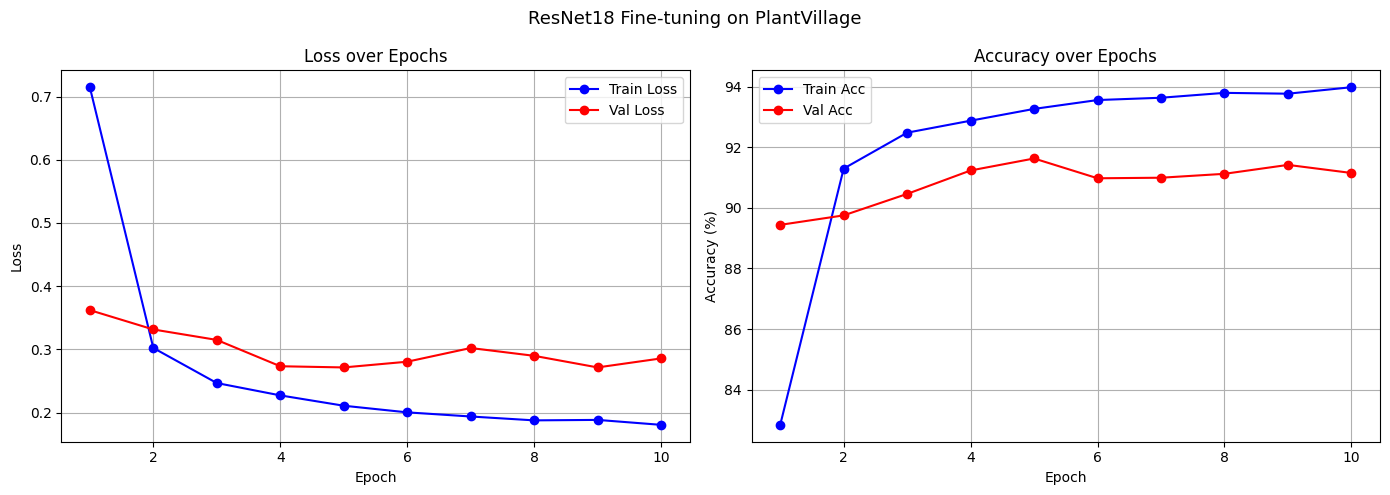

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, NUM_EPOCHS + 1)

# --- Loss curve ---
ax1.plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
ax1.plot(epochs, history['val_loss'],   'r-o', label='Val Loss')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# --- Accuracy curve ---
ax2.plot(epochs, history['train_acc'], 'b-o', label='Train Acc')
ax2.plot(epochs, history['val_acc'],   'r-o', label='Val Acc')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.suptitle('ResNet18 Fine-tuning on PlantVillage', fontsize=13)
plt.tight_layout()
plt.show()

In [20]:
# ── Download best_model.pth from Kaggle ───────────────────────────────
from IPython.display import FileLink, display
import os

model_path = 'best_model.pth'

if os.path.exists(model_path):
    print(f"✅ Model found: {os.path.getsize(model_path) / 1e6:.1f} MB")
    display(FileLink(model_path))
else:
    print("❌ best_model.pth not found — make sure training completed and the model was saved.")

✅ Model found: 44.9 MB


/kaggle/working/best_model.pth

**Summary & Fix**
-The problem: ResNet18 backbone is frozen — we're only training a single linear layer on top of it. That layer has learned everything it can. Both curves have flatlined, and the ~2.4% train/val gap isn't overfitting, it's just the ceiling of what one linear layer can extract from frozen ImageNet features applied to plant disease images.
The gap we're leaving on the table: we're at 91.75% val accuracy. Models trained end-to-end on PlantVillage routinely hit 96–98%. That ~5% gap is sitting inside the frozen layers.

**-The fix:** progressive unfreezing
Don't unfreeze everything at once — that destabilizes the pretrained weights and often makes things worse. We should do it in stages with a decreasing learning rate the deeper we go.

**Model 2:**

In [21]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze ALL layers first
for param in model.parameters():
    param.requires_grad = False

# Then selectively UNFREEZE layer4 and the final head
# ResNet18 structure: layer1 → layer2 → layer3 → layer4 → fc
for param in model.layer4.parameters():    # unfreeze layer4 (deepest conv block)
    param.requires_grad = True

# Replace and unfreeze the head
model.fc = nn.Linear(model.fc.in_features, num_classes)  # requires_grad=True by default

model = model.to(device)

# Check what's trainable now
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Frozen params   : {sum(p.numel() for p in model.parameters() if not p.requires_grad):,}")

Trainable params: 8,413,222
Frozen params   : 2,782,784


In [22]:
criterion = nn.CrossEntropyLoss()

# Lower lr is critical here — layer4 weights are already good
# a high lr would destroy them, 1e-4 nudges them gently
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4   # was 1e-3 before, now 10x smaller
)

In [23]:
model.eval()
with torch.no_grad():
    sample = images[:4].to(device)
    out = model(sample)
    print(f"input shape: {sample.shape}")
    print(f"output shape: {out.shape}") #4 rows of 38 scores
    print(f"sample logits: {out[0, :5]}") #5 raw scores for first image

input shape: torch.Size([4, 3, 224, 224])
output shape: torch.Size([4, 38])
sample logits: tensor([ 0.6397,  2.3025, -0.7889,  1.2756,  0.8731], device='cuda:0')


In [24]:
NUM_EPOCHS = 10  # how many times we loop over the entire training set

# Lists to record history for plotting later
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

best_val_acc = 0.0  # we'll use this to save the best model

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 40)
    
    # --- Train for one full pass over training data ---
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    
    # --- Evaluate on validation data (no weight updates) ---
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # --- Save metrics ---
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # --- Print epoch summary ---
    print(f"\n  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")
    
    # --- Save the model if it's the best so far ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')  # saves only the weights, not the whole model
        print(f"  ✅ New best model saved! Val Acc: {val_acc:.2f}%")

print(f"\nTraining complete. Best Val Accuracy: {best_val_acc:.2f}%")


Epoch 1/10
----------------------------------------
 batch 100/1358|loss: 0.6486| Acc: 64.00%
 batch 200/1358|loss: 0.4572| Acc: 76.36%
 batch 300/1358|loss: 0.2352| Acc: 81.98%
 batch 400/1358|loss: 0.2536| Acc: 85.12%
 batch 500/1358|loss: 0.1282| Acc: 87.32%
 batch 600/1358|loss: 0.0936| Acc: 88.74%
 batch 700/1358|loss: 0.0455| Acc: 89.75%
 batch 800/1358|loss: 0.1950| Acc: 90.60%
 batch 900/1358|loss: 0.1785| Acc: 91.28%
 batch 1000/1358|loss: 0.0555| Acc: 91.85%
 batch 1100/1358|loss: 0.0814| Acc: 92.29%
 batch 1200/1358|loss: 0.1176| Acc: 92.73%
 batch 1300/1358|loss: 0.0480| Acc: 93.10%

  Train Loss: 0.2862 | Train Acc: 93.31%
  Val   Loss: 0.0923 | Val   Acc: 97.17%
  ✅ New best model saved! Val Acc: 97.17%

Epoch 2/10
----------------------------------------
 batch 100/1358|loss: 0.1363| Acc: 98.00%
 batch 200/1358|loss: 0.0180| Acc: 97.88%
 batch 300/1358|loss: 0.0437| Acc: 97.96%
 batch 400/1358|loss: 0.0885| Acc: 98.02%
 batch 500/1358|loss: 0.3851| Acc: 98.06%
 batch 60

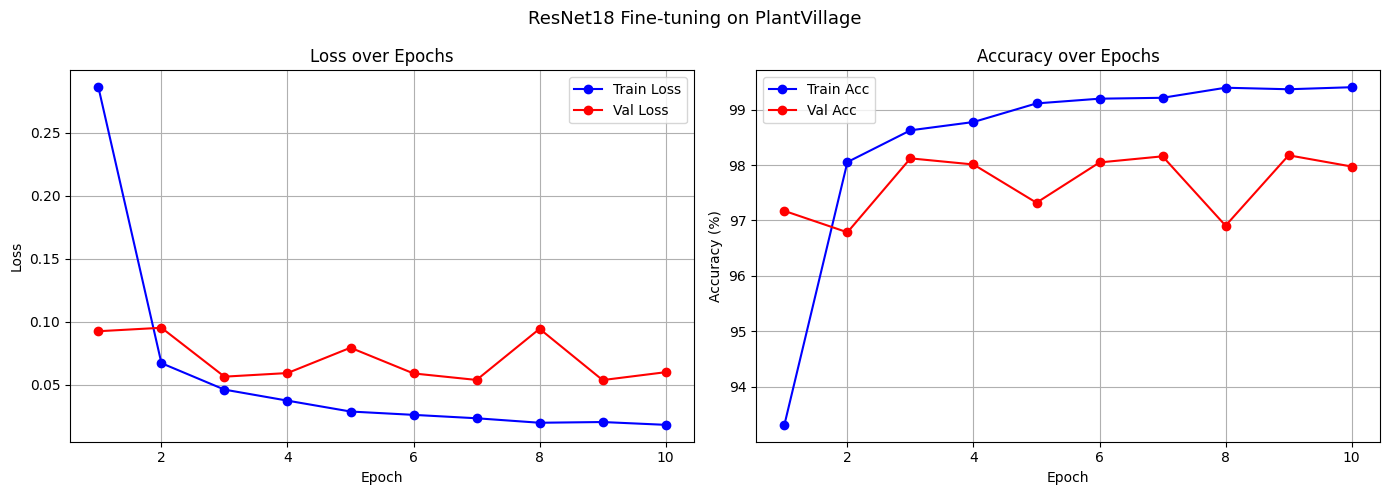

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, NUM_EPOCHS + 1)

# --- Loss curve ---
ax1.plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
ax1.plot(epochs, history['val_loss'],   'r-o', label='Val Loss')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# --- Accuracy curve ---
ax2.plot(epochs, history['train_acc'], 'b-o', label='Train Acc')
ax2.plot(epochs, history['val_acc'],   'r-o', label='Val Acc')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.suptitle('ResNet18 Fine-tuning on PlantVillage', fontsize=13)
plt.tight_layout()
plt.show()

In [26]:
# ── Download best_model.pth from Kaggle ───────────────────────────────
from IPython.display import FileLink, display
import os

model_path = 'best_model.pth'

if os.path.exists(model_path):
    print(f"✅ Model found: {os.path.getsize(model_path) / 1e6:.1f} MB")
    display(FileLink(model_path))
else:
    print("❌ best_model.pth not found — make sure training completed and the model was saved.")

✅ Model found: 44.9 MB


/kaggle/working/best_model.pth

-**The good news:** model is genuinely strong. 98%+ train accuracy and ~98.25% best val accuracy on a 38-class problem is excellent — that's a well-trained model.

-**The concern:** the accuracy chart on the right. Train accuracy (blue) keeps climbing smoothly and is now approaching 99.5%. Val accuracy (red) plateaued around epoch 4 at ~98.2% and has been bouncing between 97–98.2% ever since. Meanwhile train loss is near zero while val loss oscillates between 0.05–0.10. Train accuracy kept climbing every single epoch while val accuracy stopped climbing and started oscillating. 

This is mild overfitting— and it's the real kind this time, not the capacity saturation we saw before. The gap is small but the pattern is textbook: train curve still improving, val curve stuck. The model is starting to memorize training-specific details that don't generalize.
The good news is your best model was saved at epoch 4 (98.25%), which is exactly right — our checkpoint saved before the drift started.

**Model3:**

In [27]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),          # ADD
    transforms.RandomRotation(15),            # ADD
    transforms.ColorJitter(                   # ADD
        brightness=0.3,
        contrast=0.3,
        saturation=0.3
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# val_transforms — KEEP EXACTLY AS IS, never augment validation
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [28]:
DATA_DIR= '/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color'

#imagefolder eads the folder structure automatically
#folder name-> class label
full_dataset = datasets.ImageFolder(root=DATA_DIR)

#check what wad loaded
print(f"total images: {len(full_dataset)}")
print(f"classes: {len(full_dataset.classes)}")
print(f"first 5 classes: {full_dataset.classes[:5]} ")

total images: 54305
classes: 38
first 5 classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy'] 


In [29]:
#split: 80% train 20% test
from torch.utils.data import Subset
# two separate dataset objects, transforms baked in from the start
train_dataset_full = datasets.ImageFolder(root=DATA_DIR, transform=train_transforms)
val_dataset_full   = datasets.ImageFolder(root=DATA_DIR, transform=val_transforms)

total      = len(train_dataset_full)
train_size = int(0.8 * total)
val_size   = total - train_size
# same indices for both so they see the same images
indices     = torch.randperm(total, generator=torch.Generator().manual_seed(42)).tolist()
train_data  = Subset(train_dataset_full, indices[:train_size])
val_data    = Subset(val_dataset_full,   indices[train_size:])

full_dataset = train_dataset_full  # keep this for .classes reference later

print(f"Total images : {total}")
print(f"Train size   : {train_size}")
print(f"Val size     : {val_size}")
print(f"Total classes: {len(full_dataset.classes)}")


Total images : 54305
Train size   : 43444
Val size     : 10861
Total classes: 38


In [30]:
num_classes = len(full_dataset.classes)

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(model.fc.in_features, num_classes)
)

model = model.to(device)

print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Frozen params   : {sum(p.numel() for p in model.parameters() if not p.requires_grad):,}")

Trainable params: 8,413,222
Frozen params   : 2,782,784


In [31]:
import torch

state_dict = torch.load('/kaggle/input/datasets/eyalatiri/bestmodel2/best_model (1).pth', map_location=device)

# Remap old keys → new keys
state_dict['fc.1.weight'] = state_dict.pop('fc.weight')
state_dict['fc.1.bias']   = state_dict.pop('fc.bias')

model.load_state_dict(state_dict)
print("✅ Loaded and remapped weights successfully!")

✅ Loaded and remapped weights successfully!


In [32]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4    # ADD — this is the key change
)

In [33]:
NUM_EPOCHS = 20

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

best_val_acc = 0.0
patience = 4
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 40)

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"\n  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        epochs_no_improve = 0
        print(f"  ✅ New best model saved! Val Acc: {val_acc:.2f}%")
    else:
        epochs_no_improve += 1
        print(f"  No improvement ({epochs_no_improve}/{patience})")
        if epochs_no_improve >= patience:
            print(f"\n🛑 Early stopping at epoch {epoch+1}. Best: {best_val_acc:.2f}%")
            break

print(f"\nTraining complete. Best Val Accuracy: {best_val_acc:.2f}%")


Epoch 1/20
----------------------------------------
 batch 100/1358|loss: 0.0118| Acc: 98.56%
 batch 200/1358|loss: 0.0052| Acc: 99.00%
 batch 300/1358|loss: 0.0337| Acc: 99.06%
 batch 400/1358|loss: 0.1557| Acc: 98.98%
 batch 500/1358|loss: 0.0227| Acc: 98.86%
 batch 600/1358|loss: 0.0062| Acc: 98.77%
 batch 700/1358|loss: 0.0093| Acc: 98.75%
 batch 800/1358|loss: 0.0176| Acc: 98.84%
 batch 900/1358|loss: 0.0408| Acc: 98.85%
 batch 1000/1358|loss: 0.0983| Acc: 98.84%
 batch 1100/1358|loss: 0.0046| Acc: 98.86%
 batch 1200/1358|loss: 0.0570| Acc: 98.86%
 batch 1300/1358|loss: 0.0435| Acc: 98.86%

  Train Loss: 0.0361 | Train Acc: 98.85%
  Val   Loss: 0.0654 | Val   Acc: 98.01%
  ✅ New best model saved! Val Acc: 98.01%

Epoch 2/20
----------------------------------------
 batch 100/1358|loss: 0.0054| Acc: 99.00%
 batch 200/1358|loss: 0.0127| Acc: 99.17%
 batch 300/1358|loss: 0.0022| Acc: 99.11%
 batch 400/1358|loss: 0.0025| Acc: 99.12%
 batch 500/1358|loss: 0.0163| Acc: 99.09%
 batch 60

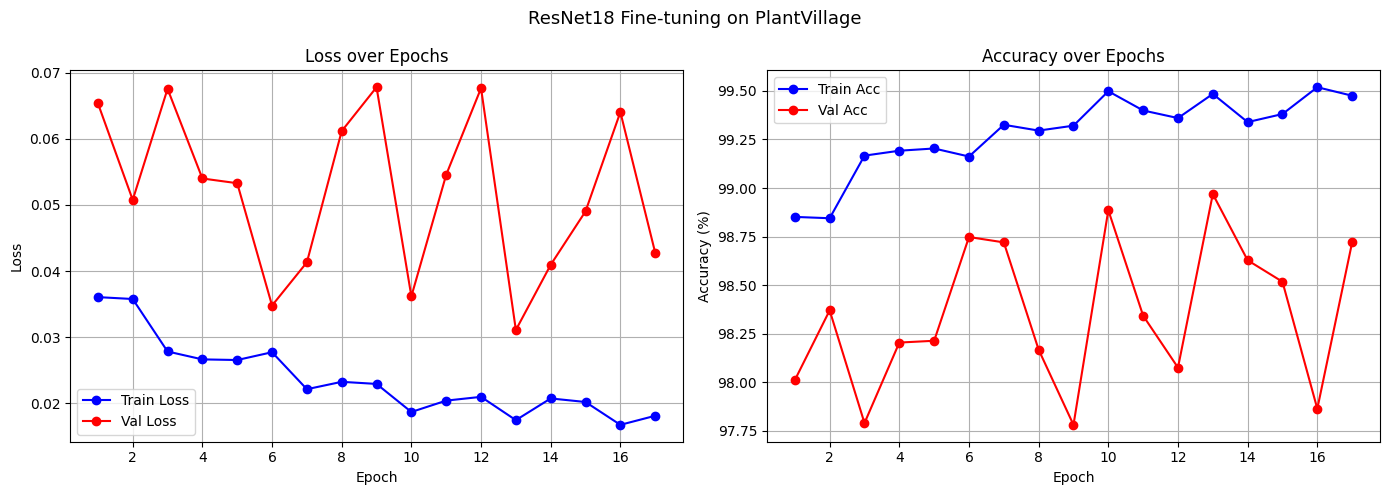

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history['train_loss']) + 1)  # use actual epochs ran, not NUM_EPOCHS

# --- Loss curve ---
ax1.plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
ax1.plot(epochs, history['val_loss'],   'r-o', label='Val Loss')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# --- Accuracy curve ---
ax2.plot(epochs, history['train_acc'], 'b-o', label='Train Acc')
ax2.plot(epochs, history['val_acc'],   'r-o', label='Val Acc')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.suptitle('ResNet18 Fine-tuning on PlantVillage', fontsize=13)
plt.tight_layout()
plt.show()

The real problem is the learning rate is too high. Look at the val loss curve — it hit its best at epoch 4 (0.041) then started jumping around wildly (0.07 → 0.06 → 0.09 → 0.09). That's not overfitting, that's the optimizer overshooting the optimal point. The model finds a good valley then bounces right out of it.
Train loss keeps smoothly decreasing while val loss oscillates — classic sign that lr=1e-4 is too aggressive for fine-tuning at this stage.

****

**Model 4:**

In [35]:
model.load_state_dict(torch.load('best_model.pth', map_location=device))
print("Loaded best_model.pth — continuing from 98.64%%")

Loaded best_model.pth — continuing from 98.64%%


In [36]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-5,        # down from 1e-4 — more careful steps
    weight_decay=1e-4
)

In [37]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,     # halve the lr when plateauing
    patience=6,
)
NUM_EPOCHS = 20

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

best_val_acc = 0.0
patience = 4
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 40)

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    # then inside your training loop, after validate():
    scheduler.step(val_acc)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"\n  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        epochs_no_improve = 0
        print(f"  ✅ New best model saved! Val Acc: {val_acc:.2f}%")
    else:
        epochs_no_improve += 1
        print(f"  No improvement ({epochs_no_improve}/{patience})")
        if epochs_no_improve >= patience:
            print(f"\n🛑 Early stopping at epoch {epoch+1}. Best: {best_val_acc:.2f}%")
            break

print(f"\nTraining complete. Best Val Accuracy: {best_val_acc:.2f}%")



Epoch 1/20
----------------------------------------
 batch 100/1358|loss: 0.0126| Acc: 99.69%
 batch 200/1358|loss: 0.0096| Acc: 99.73%
 batch 300/1358|loss: 0.0006| Acc: 99.73%
 batch 400/1358|loss: 0.0004| Acc: 99.75%
 batch 500/1358|loss: 0.0013| Acc: 99.76%
 batch 600/1358|loss: 0.0009| Acc: 99.74%
 batch 700/1358|loss: 0.0006| Acc: 99.75%
 batch 800/1358|loss: 0.0044| Acc: 99.77%
 batch 900/1358|loss: 0.0015| Acc: 99.75%
 batch 1000/1358|loss: 0.0297| Acc: 99.76%
 batch 1100/1358|loss: 0.0009| Acc: 99.76%
 batch 1200/1358|loss: 0.0288| Acc: 99.78%
 batch 1300/1358|loss: 0.0010| Acc: 99.77%

  Train Loss: 0.0097 | Train Acc: 99.76%
  Val   Loss: 0.0286 | Val   Acc: 99.07%
  ✅ New best model saved! Val Acc: 99.07%

Epoch 2/20
----------------------------------------
 batch 100/1358|loss: 0.0002| Acc: 99.75%
 batch 200/1358|loss: 0.0020| Acc: 99.80%
 batch 300/1358|loss: 0.0087| Acc: 99.82%
 batch 400/1358|loss: 0.0142| Acc: 99.83%
 batch 500/1358|loss: 0.0006| Acc: 99.81%
 batch 60

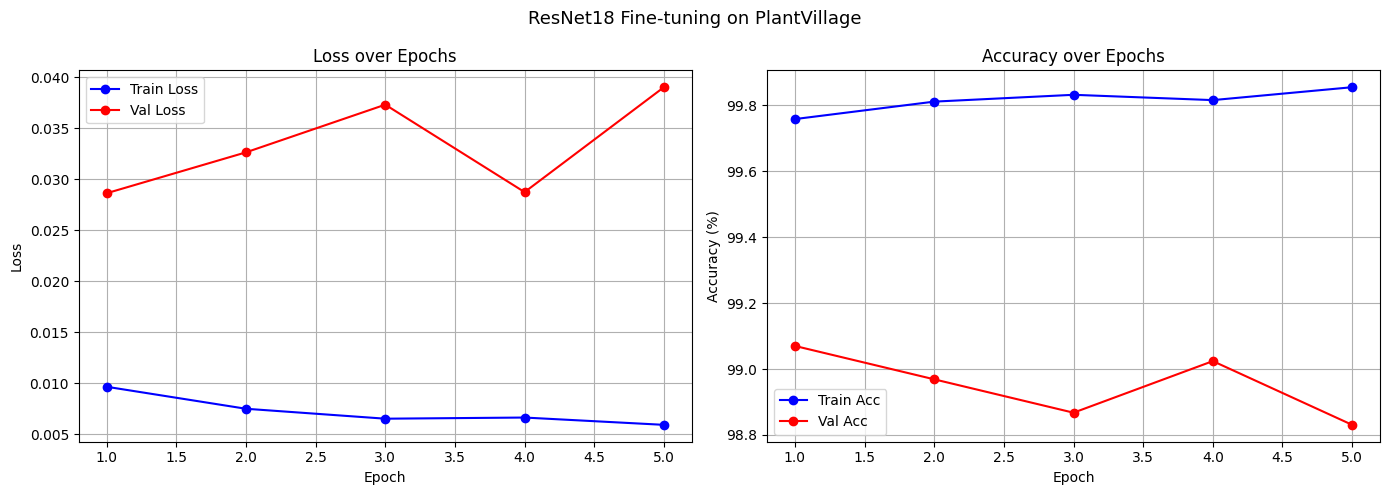

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history['train_loss']) + 1)  # use actual epochs ran, not NUM_EPOCHS

# --- Loss curve ---
ax1.plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
ax1.plot(epochs, history['val_loss'],   'r-o', label='Val Loss')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# --- Accuracy curve ---
ax2.plot(epochs, history['train_acc'], 'b-o', label='Train Acc')
ax2.plot(epochs, history['val_acc'],   'r-o', label='Val Acc')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.suptitle('ResNet18 Fine-tuning on PlantVillage', fontsize=13)
plt.tight_layout()
plt.show()

In [39]:
# ── Download best_model.pth from Kaggle ───────────────────────────────
from IPython.display import FileLink, display
import os

model_path = 'best_model.pth'

if os.path.exists(model_path):
    print(f"✅ Model found: {os.path.getsize(model_path) / 1e6:.1f} MB")
    display(FileLink(model_path))
else:
    print("❌ best_model.pth not found — make sure training completed and the model was saved.")

✅ Model found: 44.9 MB


/kaggle/working/best_model.pth

**Evaluation Metrics**

In [40]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(
    all_labels, all_preds,
    target_names=full_dataset.classes,
    digits=4
))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    0.9692    0.9844       130
                                 Apple___Black_rot     1.0000    1.0000    1.0000       120
                          Apple___Cedar_apple_rust     1.0000    0.9796    0.9897        49
                                   Apple___healthy     1.0000    0.9889    0.9944       359
                               Blueberry___healthy     0.9764    1.0000    0.9881       290
          Cherry_(including_sour)___Powdery_mildew     0.9881    1.0000    0.9940       249
                 Cherry_(including_sour)___healthy     1.0000    1.0000    1.0000       166
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.8851    0.8953    0.8902        86
                       Corn_(maize)___Common_rust_     1.0000    1.0000    1.0000       225
               Corn_(maize)___Northern_Leaf_Blight     0.9548    0.9500    0.95

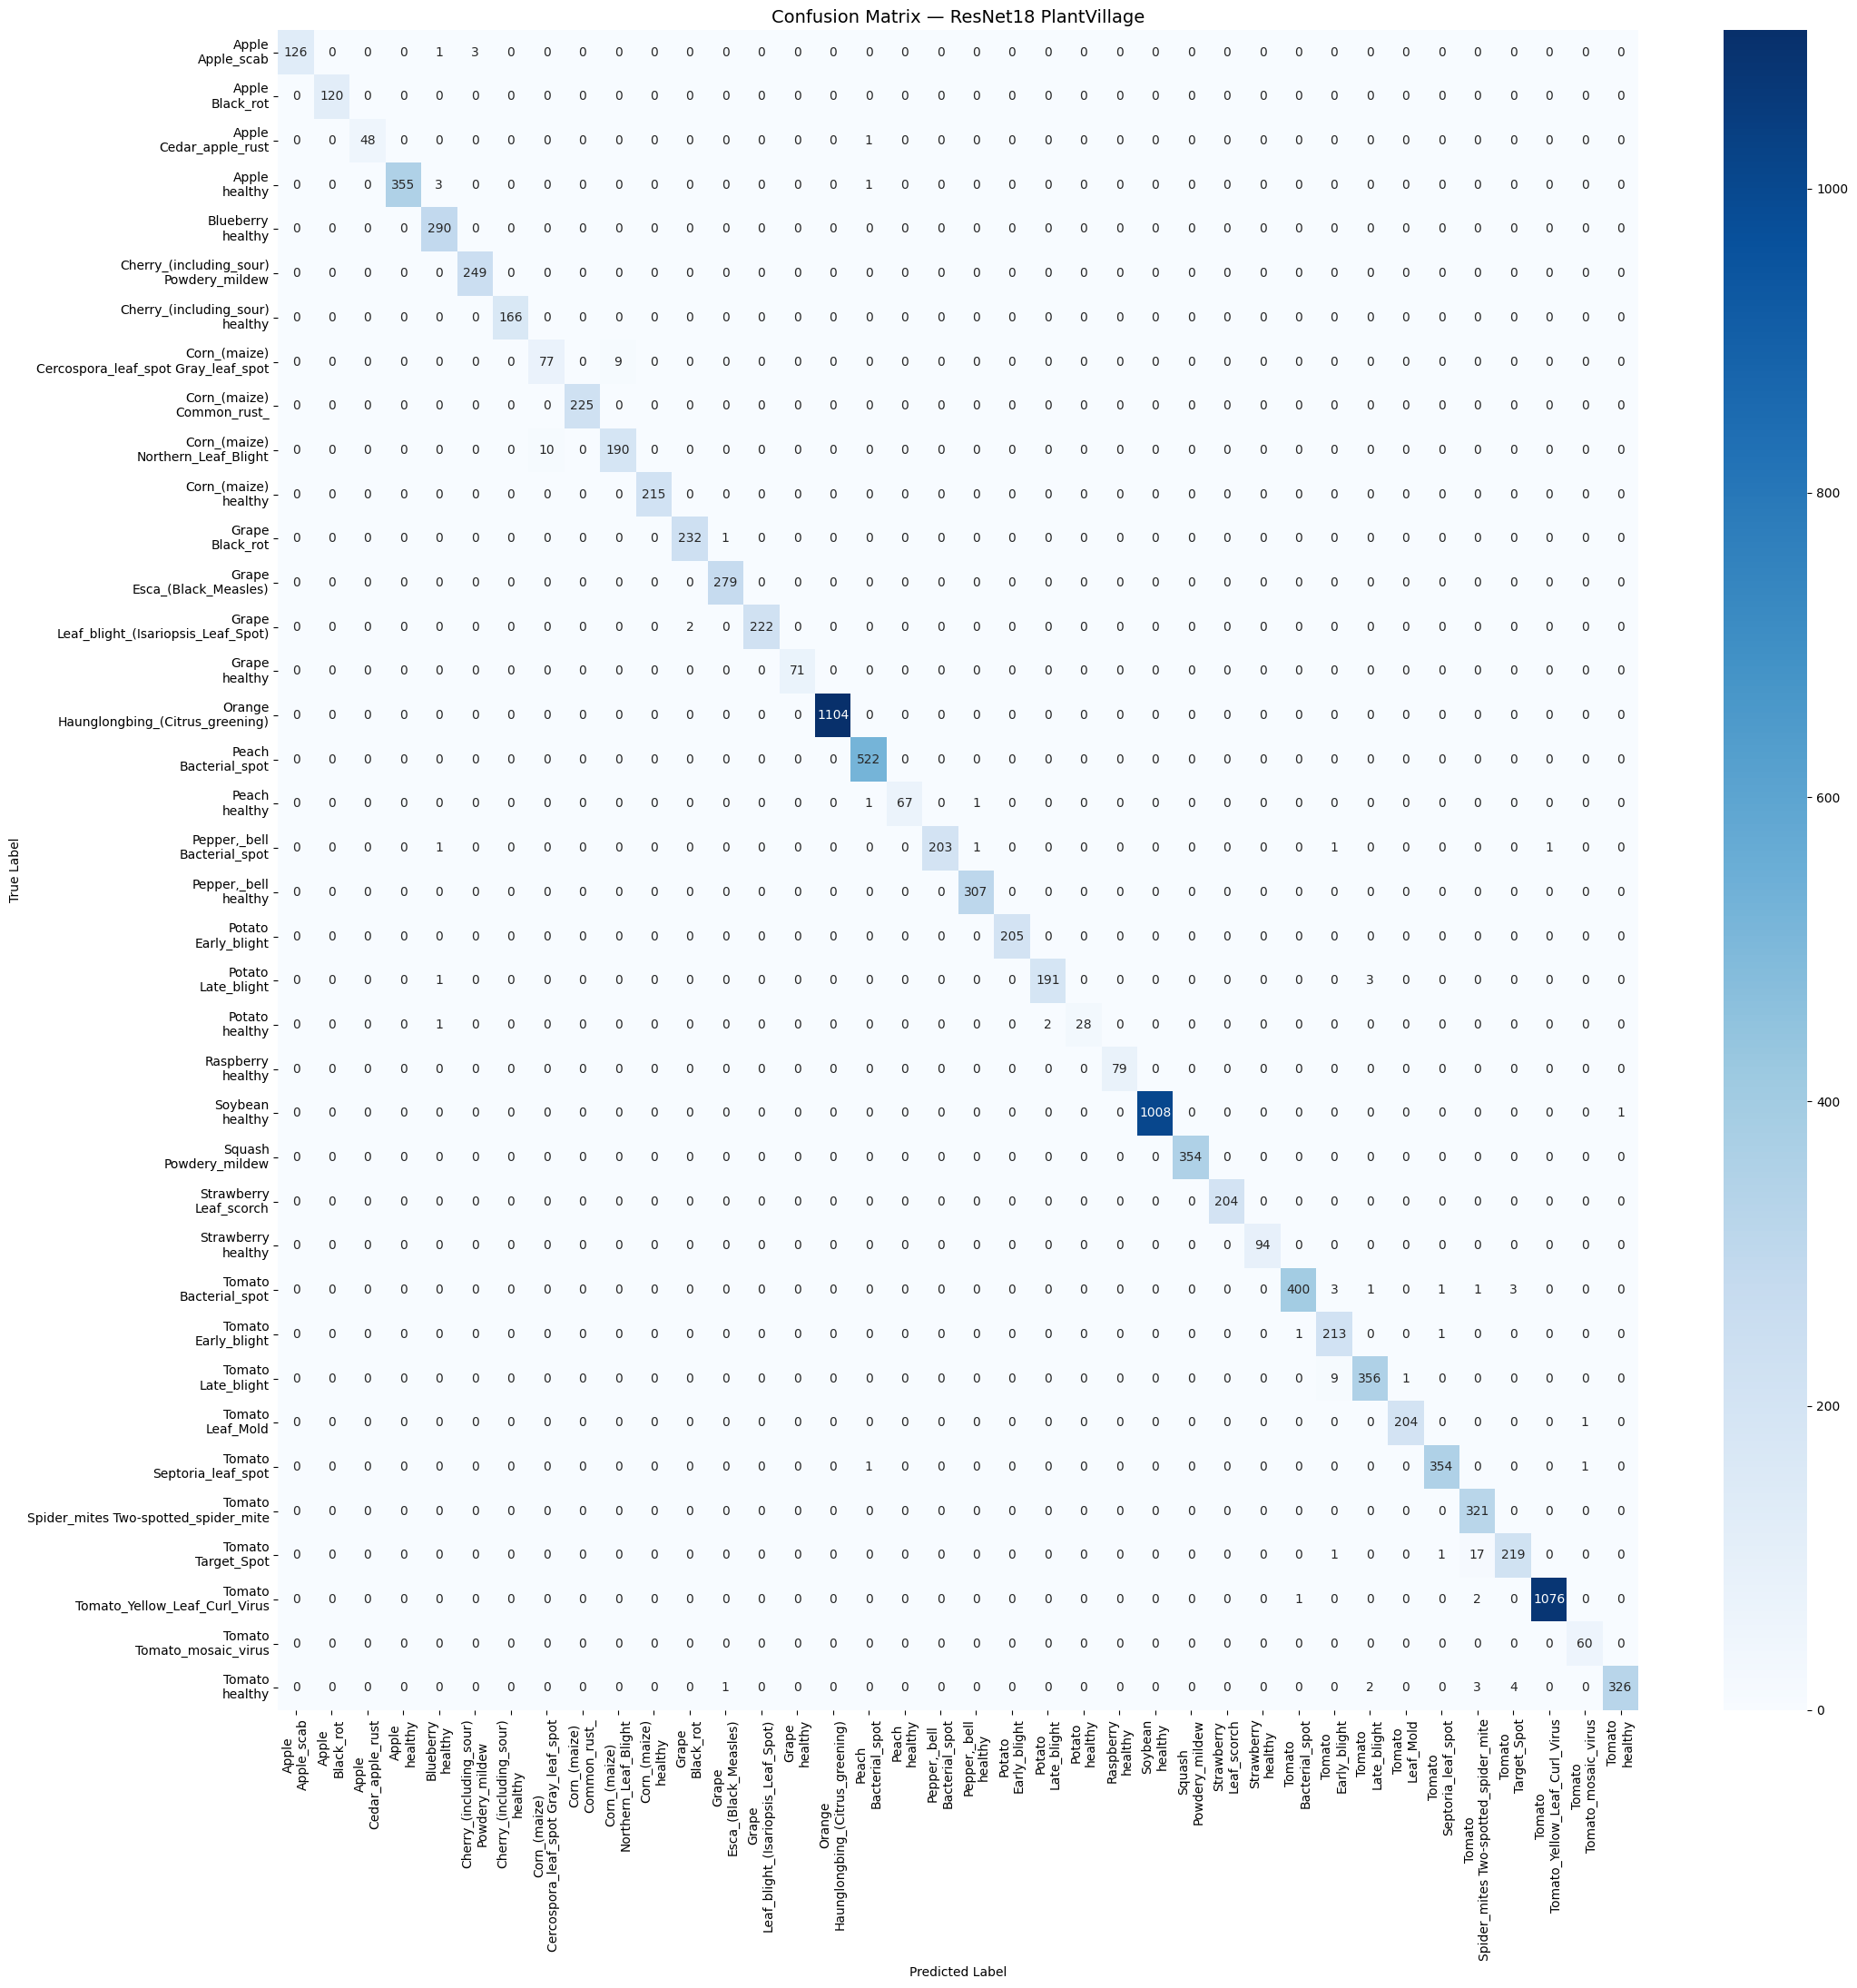

In [41]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(22, 22))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=[c.replace('___', '\n') for c in full_dataset.classes],
            yticklabels=[c.replace('___', '\n') for c in full_dataset.classes],
            cmap='Blues')
plt.title('Confusion Matrix — ResNet18 PlantVillage', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

The diagonal is almost entirely dark blue — meaning the model predicts the correct class nearly every time. The off-diagonal values are almost all zeros. For a 38-class problem this is about as clean as it gets.

**gradio cell:**



In [43]:
# pip install gradio first
!pip install gradio -q

import gradio as gr
from PIL import Image as PILImage

infer_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

class_names = full_dataset.classes
model.eval()

def predict(image):
    tensor = infer_transforms(image).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(tensor)
        probs = torch.softmax(outputs, dim=1)[0]
    top5 = probs.topk(5)
    return {
        class_names[i].replace('___', ' — ').replace('_', ' '): float(p)
        for i, p in zip(top5.indices, top5.values)
    }

gr.Interface(
    fn=predict,
    inputs=gr.Image(type='pil'),
    outputs=gr.Label(num_top_classes=5),
    title='🌿 Plant Disease Classifier',
    description='Upload a leaf image — model will predict the disease across 38 classes'
).launch(share=True)  # share=True gives you a public link


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://1886740b7ad2e4f3a6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
